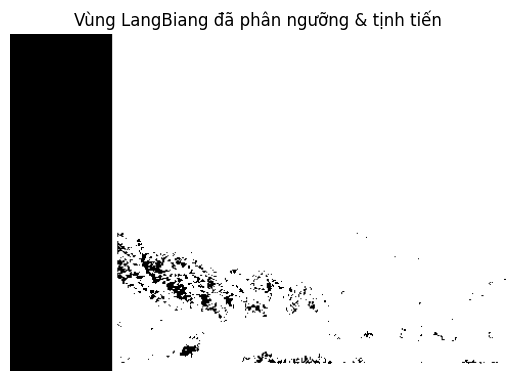

In [5]:
from PIL import Image
import numpy as np
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt

# Bước 1: Mở ảnh gốc từ thư mục 'exercise' và chuyển sang ảnh xám (grayscale)
image = Image.open('exercise/dalat.jpg').convert('L')

# Bước 2: Cắt vùng LangBiang từ ảnh gốc (tọa độ: left, top, right, bottom)
cropped = image.crop((15, 20, 500, 350))

# Bước 3: Chuyển ảnh cắt sang dạng mảng numpy để xử lý
a = np.array(cropped)

# Bước 4: Áp dụng thuật toán Otsu để tìm ngưỡng phân tách sáng/tối tự động
otsu_thresh = threshold_otsu(a)

# Dùng ngưỡng Otsu nhân với 0.3 để làm ngưỡng mới, tạo ảnh nhị phân
final_thresh = otsu_thresh * 0.3
binary = (a > final_thresh).astype(np.uint8) * 255

# Bước 5: Tịnh tiến ảnh nhị phân sang phải 100 pixel
# - Nếu ảnh đủ rộng, dịch phải bằng cách tạo ảnh mới và chép dữ liệu cũ vào
# - Nếu ảnh quá hẹp thì giữ nguyên
shifted = np.zeros_like(binary)
if binary.shape[1] > 100:
    shifted[:, 100:] = binary[:, :-100]
else:
    shifted = binary

# Bước 6: Lưu ảnh kết quả sau khi tịnh tiến vào file mới
result_img = Image.fromarray(shifted)
result_img.save('lang_biang.jpg')

# Bước 7: Hiển thị ảnh kết quả bằng matplotlib
plt.imshow(shifted, cmap='gray')
plt.title('Vùng LangBiang đã phân ngưỡng & tịnh tiến')
plt.axis('off')
plt.show()


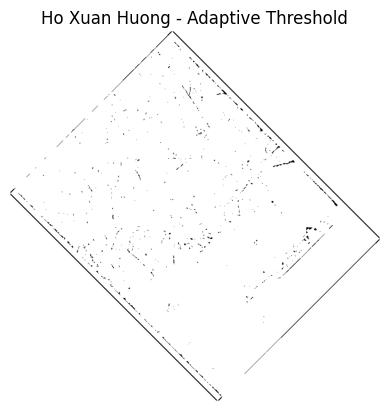

In [4]:
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Bước 1: Mở ảnh gốc từ thư mục 'exercise' và chuyển sang ảnh xám (grayscale)
image = Image.open('exercise/dalat.jpg').convert('L')

# Bước 2: Cắt vùng Hồ Xuân Hương từ ảnh theo tọa độ (left, top, right, bottom)
cropped = image.crop((500, 30, 1000, 670))

# Bước 3: Xoay vùng chọn 45 độ theo chiều kim đồng hồ, mở rộng khung để không bị cắt góc
rotated = cropped.rotate(45, expand=True)

# Bước 4: Chuyển ảnh xoay thành mảng numpy để xử lý bằng OpenCV
a = np.array(rotated)

# Bước 5: Áp dụng Adaptive Threshold để nhấn mạnh chi tiết ảnh
# - Sử dụng phương pháp trung bình vùng lân cận (MEAN_C)
# - blockSize = 11 (kích thước vùng lân cận), C = 60 (giá trị trừ đi sau trung bình)
adaptive = cv2.adaptiveThreshold(
    a,                           # ảnh đầu vào dạng uint8
    255,                         # giá trị trắng tối đa
    cv2.ADAPTIVE_THRESH_MEAN_C, # phương pháp adaptive: dùng trung bình cục bộ
    cv2.THRESH_BINARY,          # kiểu nhị phân (đen-trắng)
    blockSize=11,               # kích thước vùng lấy trung bình (số lẻ)
    C=60                        # giá trị trừ sau khi tính trung bình
)

# Bước 6: Chuyển ảnh kết quả từ numpy array thành ảnh PIL và lưu ra file
result_img = Image.fromarray(adaptive)
result_img.save('ho_xuan_huong.jpg')

# Bước 7: Hiển thị ảnh kết quả bằng matplotlib
plt.imshow(adaptive, cmap='gray')
plt.title('Ho Xuan Huong - Adaptive Threshold')
plt.axis('off')
plt.show()


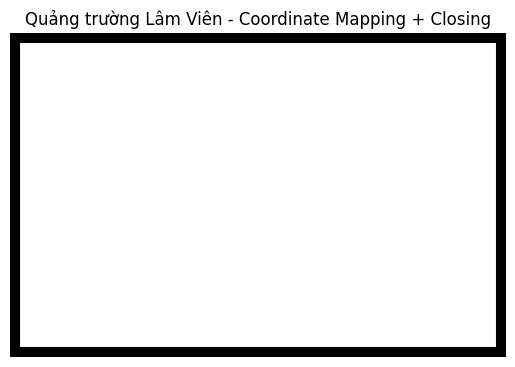

In [6]:
from PIL import Image
import numpy as np
import scipy.ndimage as nd
import matplotlib.pyplot as plt

# Bước 1: Mở ảnh gốc từ thư mục và chuyển sang ảnh xám (grayscale)
image = Image.open('exercise/dalat.jpg').convert('L')

# Bước 2: Cắt vùng Quảng trường Lâm Viên từ ảnh gốc
# (tọa độ (left, top, right, bottom) có thể điều chỉnh tùy ảnh)
cropped = image.crop((1000, 20, 1490, 340))

# Bước 3: Chuyển ảnh đã cắt thành mảng numpy để xử lý
a = np.array(cropped)

# Bước 4: Áp dụng kỹ thuật Coordinate Mapping để dịch ảnh sang phải 50px
# - Tạo lưới tọa độ (y, x) của từng điểm ảnh
coords = np.indices(a.shape)
coords_x = coords[1]           # tọa độ x
coords_y = coords[0]           # tọa độ y

# - Dịch tọa độ x sang trái 50px (tức là hình sẽ bị đẩy sang phải)
mapped_x = coords_x - 50
mapped_y = coords_y

# - Đảm bảo tọa độ không vượt ra ngoài kích thước ảnh
mapped_x = np.clip(mapped_x, 0, a.shape[1]-1)

# - Lấy giá trị pixel từ ảnh gốc theo tọa độ mới
mapped = a[mapped_y, mapped_x]

# Bước 5: Áp dụng Binary Closing để làm mịn và lấp lỗ nhỏ
# - Định nghĩa kernel hình dấu cộng (cross-shaped structuring element)
s = [[0,1,0],
     [1,1,1],
     [0,1,0]]

# - Áp dụng phép closing nhiều lần (10 lần)
closed = nd.binary_closing(mapped, structure=s, iterations=10)

# Bước 6: Chuyển kết quả từ boolean array về ảnh grayscale và lưu file
result_img = Image.fromarray((closed * 255).astype(np.uint8))
result_img.save('quan_truong_lam_vien.jpg')

# Bước 7: Hiển thị ảnh kết quả
plt.imshow(result_img, cmap='gray')
plt.title('Quảng trường Lâm Viên - Coordinate Mapping + Closing')
plt.axis('off')
plt.show()


=== MENU ===
Geometric Transformation:
 1. coordinate_mapping
 2. rotate
 3. scale
 4. shift
Segment:
 5. adaptive_threshold
 6. binary_dilation
 7. binary_erosion
 8. otsu

Bạn có thể nhập 1 số (ví dụ: 2) hoặc nhiều số cách nhau (ví dụ: 2 6)
Xoay ảnh 45 độ


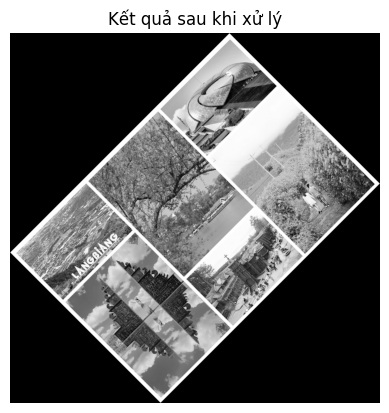

In [7]:
from PIL import Image
import numpy as np
import scipy.ndimage as nd
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt

# Mở ảnh gốc và chuyển sang ảnh xám
img = Image.open('exercise/dalat.jpg').convert('L')
a = np.array(img)

# === CÁC HÀM XỬ LÝ ẢNH ===

def coordinate_mapping(image):
    print("Áp dụng Coordinate Mapping: tịnh tiến sang phải 50px")
    coords = np.indices(image.shape)                      # Tạo lưới tọa độ
    mapped_x = np.clip(coords[1] - 50, 0, image.shape[1]-1)  # Dịch trục x
    mapped = image[coords[0], mapped_x]                   # Lấy pixel mới
    return mapped

def rotate(image):
    print("Xoay ảnh 45 độ")
    return nd.rotate(image, 45, reshape=True)             # Xoay và mở rộng khung ảnh

def scale(image):
    print("Phóng to ảnh lên 1.5 lần")
    return nd.zoom(image, 1.5)                            # Phóng to bằng zoom

def shift(image):
    print("Tịnh tiến ảnh xuống 50px")
    return nd.shift(image, (50, 0))                       # Dịch xuống 50px theo trục y

def adaptive_threshold(image):
    print("Dùng ngưỡng Adaptive Threshold với ngưỡng C=60")
    import cv2
    return cv2.adaptiveThreshold(
        image.astype(np.uint8), 255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY, 11, 60)                        # Phân ngưỡng theo vùng

def binary_dilation(image):
    print("Thực hiện Binary Dilation")
    return nd.binary_dilation(image, iterations=10) * 255  # Giãn vùng trắng

def binary_erosion(image):
    print("Thực hiện Binary Erosion")
    return nd.binary_erosion(image, iterations=10) * 255   # Co vùng trắng

def otsu(image):
    print("Dùng phương pháp Otsu để phân ngưỡng")
    thresh = threshold_otsu(image)                         # Tính ngưỡng tự động
    return (image > thresh).astype(np.uint8) * 255         # Tạo ảnh nhị phân


# === MENU LỰA CHỌN ===

# Nhóm hàm biến đổi hình học
menu_geo = {
    '1': ('coordinate_mapping', coordinate_mapping),
    '2': ('rotate', rotate),
    '3': ('scale', scale),
    '4': ('shift', shift)
}

# Nhóm hàm xử lý phân đoạn ảnh
menu_seg = {
    '5': ('adaptive_threshold', adaptive_threshold),
    '6': ('binary_dilation', binary_dilation),
    '7': ('binary_erosion', binary_erosion),
    '8': ('otsu', otsu)
}

# Hiển thị menu
print("=== MENU ===")
print("Geometric Transformation:")
for k, v in menu_geo.items():
    print(f" {k}. {v[0]}")

print("Segment:")
for k, v in menu_seg.items():
    print(f" {k}. {v[0]}")

print("\nBạn có thể nhập 1 số (ví dụ: 2) hoặc nhiều số cách nhau (ví dụ: 2 6)")

# Nhập lựa chọn từ người dùng
choices = input("Nhập lựa chọn của bạn: ").split()

# Khởi tạo kết quả ban đầu là ảnh gốc
result = a.copy()

# Áp dụng các hàm theo lựa chọn
for c in choices:
    if c in menu_geo:
        result = menu_geo[c][1](result)
    elif c in menu_seg:
        result = menu_seg[c][1](result)
    else:
        print(f"Không có chức năng số {c}")

# Chuyển đổi kiểu dữ liệu ảnh nếu cần
if result.dtype == bool:
    result = (result * 255).astype(np.uint8)
elif result.dtype != np.uint8:
    result = result.astype(np.uint8)

# Hiển thị kết quả cuối cùng
plt.imshow(result, cmap='gray')
plt.axis('off')
plt.title('Kết quả sau khi xử lý')
plt.show()
